# Step 4 - a deep-learning forecast of next-month market weather (calm / normal / stormy)

We built the whole thing from scratch in numpy: the network, the backward pass, the optimisers, the search, and the honest test. This notebook is where the deep-learning skill gets unleashed on the market problem - but under strict discipline, because the same freedom that lets a network fit anything also lets it fool us.

**The discipline (fixed before we start).** Select on the VALIDATION split only; open the sealed TEST split exactly once; keep four markets entirely held-out as a transfer test. The proven ceiling is persistence at roughly the mid-50s%, with only a small genuine edge on top. So **any test accuracy far above ~60% is an ALARM (a leak or a bug), not a triumph.**

**Aims of this notebook**

- Fix the ceiling first: three cheap baselines (majority, persistence, logistic) that any network has to beat to matter.
- Build a small MLP from scratch, and prove the hand-derived gradients are correct with a finite-difference check before we trust a single trained number.
- Sweep the whole toolbox - architectures, optimisers, activations, regularisation, and a disciplined hyperparameter search - and read every result against the ceiling.
- Open the sealed test once, judge the survivors on accuracy AND calibration AND transfer to unseen markets, then use the winner like a weather app.

*Reproducibility: every experiment seeds its own generator with `np.random.default_rng(...)`, so a fresh Run All reproduces every number below. The data path resolves whether the kernel runs from the repository root or from `notebooks/`.*

## Mau 1 - the data, an honest split, and the ceiling to beat

Before any network, we need the problem in a clean shape and a number to beat. We take a panel of daily markets, turn each into a monthly volatility series, label next month's weather as calm / normal / stormy, and split by time so the future never leaks into the past. Held-out symbols are set aside completely as a transfer test.

Imports, and the constants that define the problem: which symbols are crypto (traded 7 days, so we drop weekends), the winsorising percentiles that tame return outliers, and the four markets we seal away as a transfer test. The `ROOT` anchor lets the same path work whether the kernel starts at the repo root or inside `notebooks/`.

In [1]:
import csv, glob, os, datetime as dt, numpy as np
import matplotlib.pyplot as plt
from collections import Counter

ROOT = "." if os.path.isdir("data/panel") else ".."   # run from repo root or from notebooks/
CRYPTO = {"BTCUSD", "ETHUSD"}
WINSOR = (0.5, 99.5)
HELD_OUT = {"US2000", "NZDUSD", "ETHUSD", "UKOIL"}

def softmax(logits):                                  # shared by the logistic baseline and the network
    z = logits - logits.max(1, keepdims=True); e = np.exp(z)
    return e / e.sum(1, keepdims=True)

One function to turn a price file into clean log-returns: read closes, drop non-positive prices, drop weekends for crypto so every symbol shares a 5-day calendar, then winsorise the extreme returns so a single crash day cannot dominate the scaling.

In [2]:
def clean_returns(path, name):
    dates = []; close = []
    for r in csv.DictReader(open(path)):
        try: c = float(r["Close"])
        except: continue
        if c <= 0: continue
        dates.append(dt.date.fromisoformat(r["Date"])); close.append(c)
    if name in CRYPTO:
        k = [i for i, d in enumerate(dates) if d.weekday() < 5]
        close = [close[i] for i in k]
    r = np.diff(np.log(np.array(close)))
    lo, hi = np.percentile(r, WINSOR)
    return np.clip(r, lo, hi)

Apply it to every panel file, keyed by symbol name. We skip helper files whose names start with an underscore.

In [3]:
clean_returns_by_symbol = {
    os.path.basename(p)[:-4]: clean_returns(p, os.path.basename(p)[:-4])
    for p in sorted(glob.glob(f"{ROOT}/data/panel/*.csv"))
    if not os.path.basename(p).startswith("_")
}

A shape check, our habit before modelling: how many symbols did we load, and which ones?

In [4]:
print(f"{len(clean_returns_by_symbol)} symbols loaded")
print(sorted(clean_returns_by_symbol))

17 symbols loaded
['AUDUSD', 'BTCUSD', 'ETHUSD', 'EURUSD', 'GBPUSD', 'NZDUSD', 'UKOIL', 'US100', 'US2000', 'US30', 'US500', 'USDCAD', 'USDCHF', 'USDJPY', 'USOIL', 'XAGUSD', 'XAUUSD']


Now the features. We compress daily noise into monthly **volatility** blocks (mean absolute return over 20 trading days), z-score each block against its own trailing window so every market speaks the same units, and label a month **stormy / normal / calm** by whether its z sits above +0.5, below -0.5, or in between. The model sees $[z_t,\ z_{t-1}]$ and must predict next month's band $\text{band}(z_{t+1})$.

In [5]:
def blocks(r, B=20):
    nb = len(r) // B
    return np.array([np.mean(np.abs(r[i*B:(i+1)*B])) for i in range(nb)])

def zser(v, BW=24):
    z = np.full(len(v), np.nan)
    for i in range(BW, len(v)):
        b = v[i-BW:i]
        z[i] = (v[i] - b.mean()) / (b.std() + 1e-12)
    return z

def band(z):
    return 2 if z > 0.5 else (0 if z < -0.5 else 1)

Build the labelled dataset. For every non-held-out symbol we cut its own timeline 70 / 15 / 15 into train / validation / sealed-test-time; the four held-out symbols become a separate test-symbol set. Splitting inside each symbol by time is what keeps the future out of the past.

In [6]:
splits = {k: ([], []) for k in ["train", "val", "testT", "testS"]}
for s in clean_returns_by_symbol:
    v = blocks(clean_returns_by_symbol[s]); z = zser(v)
    idx = [t for t in range(25, len(v)-1)
           if not (np.isnan(z[t]) or np.isnan(z[t-1]) or np.isnan(z[t+1]))]
    for rank, t in enumerate(idx):
        x = [z[t], z[t-1]]; y = band(z[t+1])
        if s in HELD_OUT:
            key = "testS"
        else:
            f = rank / len(idx)
            key = "train" if f < 0.70 else ("val" if f < 0.85 else "testT")
        splits[key][0].append(x); splits[key][1].append(y)
data_lag = {k: (np.array(v[0]), np.array(v[1])) for k, v in splits.items()}

A look at each split: how big it is, its base rate (the majority-class share), and the calm / normal / stormy mix. The base rates sit near 40%, so a model that only ever guesses the majority band would score there.

In [7]:
for k, (X, y) in data_lag.items():
    br = Counter(y).most_common(1)[0][1] / len(y)
    print(f"{k:6s}: n={len(y):5d}  base-rate={100*br:.1f}%  dist={[round(100*np.mean(y==c)) for c in (0,1,2)]}")
print("held-out symbols (transfer test):", sorted(HELD_OUT))

train : n= 3000  base-rate=41.9%  dist=[42, 31, 28]
val   : n=  642  base-rate=40.3%  dist=[31, 40, 29]
testT : n=  635  base-rate=42.2%  dist=[42, 32, 26]
testS : n= 1027  base-rate=41.3%  dist=[41, 32, 27]
held-out symbols (transfer test): ['ETHUSD', 'NZDUSD', 'UKOIL', 'US2000']


Now the ceiling. Three baselines a network must beat to earn its keep: **majority** (always guess the base-rate band), **persistence** (next month = this month's band - the naive weather forecast), and **multinomial logistic** on $[z_t, z_{t-1}]$. Persistence is the honest bar; the flag fires if anything clears ~60% on a test split, because that would mean a leak, not skill.

In [8]:
def fit_log(X, y, ep=500, lr=0.5, l2=1e-3):
    Xb = np.column_stack([X, np.ones(len(X))]); W = np.zeros((Xb.shape[1], 3)); Y = np.eye(3)[y]
    for _ in range(ep):
        probs = softmax(Xb @ W)
        W -= lr * (Xb.T @ (probs - Y) / len(X) + l2 * W)
    return W
def pred_log(W, X):
    return softmax(np.column_stack([X, np.ones(len(X))]) @ W).argmax(1)
def persistence(X):
    return np.where(X[:, 0] > 0.5, 2, np.where(X[:, 0] < -0.5, 0, 1))   # current band from z_t

maj = Counter(data_lag["train"][1]).most_common(1)[0][0]
W_log = fit_log(*data_lag["train"])
print(f"{'set':11s}{'majority':>10s}{'persistence':>13s}{'logistic':>10s}")
for k in ["train", "val", "testT", "testS"]:
    X, y = data_lag[k]
    a_maj = np.mean(y == maj); a_per = np.mean(persistence(X) == y); a_log = np.mean(pred_log(W_log, X) == y)
    flag = " <-- ALARM (>60%)" if (k in ("testT", "testS") and max(a_per, a_log) > 0.60) else ""
    print(f"{k:11s}{100*a_maj:9.1f}%{100*a_per:12.1f}%{100*a_log:9.1f}%{flag}")
print("\nCEILING: persistence sits in the mid-50s%. The DL below must be judged against THIS, and anything >>60% on test = leak.")

set          majority  persistence  logistic
train           41.9%        56.4%     58.0%
val             31.2%        52.3%     51.2%
testT           42.2%        53.9%     56.4%
testS           41.3%        54.7%     53.8%

CEILING: persistence sits in the mid-50s%. The DL below must be judged against THIS, and anything >>60% on test = leak.


## Mau 2 - the network from scratch, and proof its gradients are right

Before we train anything we build the network in numpy and, crucially, **prove the backward pass is correct** with a finite-difference check. Getting this wrong is the classic silent bug: the loss still goes down, just to the wrong place. We check first, then trust.

**The forward pass.** For a batch of features $X$ (rows = months), a network with weights $W^l$ and biases $b^l$ computes, layer by layer,

$$z^l = a^{l-1} W^l + b^l, \qquad a^l = \phi(z^l)\ \text{(hidden)}, \qquad p = \mathrm{softmax}(z^L),\quad p_k = \frac{e^{z^L_k}}{\sum_j e^{z^L_j}}.$$

$\phi$ is the activation (ReLU by default). The output $p$ is a probability over {calm, normal, stormy}. Training minimises cross-entropy $J = -\frac{1}{m}\sum_i \log p_{i,\,y_i}$.

The pieces, defined once (`softmax` was already introduced with the logistic baseline). `act_f` / `act_d` are the four activations and their exact derivatives; `init` draws He-scaled random weights; `forward` runs $X \to z^1 \to a^1 \to \dots \to p$ and returns every activation and pre-activation (the backward pass needs them); `accuracy` and `probs_mlp` read predictions off the forward pass.

In [9]:
def act_f(z, kind):
    return {"relu":    np.maximum(0, z),
            "leaky":   np.where(z > 0, z, 0.01 * z),
            "tanh":    np.tanh(z),
            "sigmoid": 1 / (1 + np.exp(-np.clip(z, -30, 30)))}[kind]

def act_d(z, kind):
    if kind == "relu":  return (z > 0).astype(float)
    if kind == "leaky": return np.where(z > 0, 1.0, 0.01)
    if kind == "tanh":  return 1 - np.tanh(z) ** 2
    s = 1 / (1 + np.exp(-np.clip(z, -30, 30))); return s * (1 - s)

def init(sizes, seed):
    rng = np.random.default_rng(seed)
    weights = [rng.standard_normal((sizes[i], sizes[i+1])) * np.sqrt(2 / sizes[i]) for i in range(len(sizes)-1)]
    biases  = [np.zeros(sizes[i+1]) for i in range(len(sizes)-1)]
    return weights, biases

def forward(weights, biases, X, act="relu"):
    a = X; acts = [a]; zs = []
    for i in range(len(weights)):
        z = a @ weights[i] + biases[i]; zs.append(z)
        a = act_f(z, act) if i < len(weights) - 1 else softmax(z)
        acts.append(a)
    return acts, zs

def accuracy(weights, biases, X, y, act="relu"):
    return np.mean(forward(weights, biases, X, act)[0][-1].argmax(1) == y)

def probs_mlp(weights, biases, X, act="relu"):
    return forward(weights, biases, X, act)[0][-1]

**The backward pass, by hand.** Two facts do all the work. Softmax with cross-entropy collapses to a clean gradient at the output logits, $\partial J/\partial z^L = (p - Y)/m$ (with $Y$ the one-hot label); and each hidden layer passes the gradient back through its weights and gates it by the activation's derivative. Written one chain-rule step per line, every gradient variable named `dJ_d_<thing>`:

$$\frac{\partial J}{\partial z^L} = \frac{p - Y}{m}, \quad
\frac{\partial J}{\partial W^l} = (a^{l-1})^\top \frac{\partial J}{\partial z^l}, \quad
\frac{\partial J}{\partial b^l} = \sum_{\text{rows}} \frac{\partial J}{\partial z^l}, \quad
\frac{\partial J}{\partial z^{l-1}} = \Big(\frac{\partial J}{\partial z^l} W^{l\top}\Big) \odot \phi'(z^{l-1}).$$

The surest test that we got this right is finite differences: nudge one weight by $\pm\delta$, recompute the loss both ways, and compare $(J_+ - J_-)/2\delta$ against the analytic gradient. Below we spell the analytic gradient out as a FORWARD / BACKWARD block for a small two-layer net and check it entry by entry.

In [10]:
def cross_entropy(weights, biases, X, y):
    probs = forward(weights, biases, X, "relu")[0][-1]
    return -np.mean(np.log(probs[np.arange(len(y)), y] + 1e-12))

def analytic_gradients(weights, biases, X, y):
    W1, W2 = weights; b1, b2 = biases
    m = len(X); one_hot = np.eye(3)[y]
    # ===================== FORWARD =====================
    z1     = X @ W1 + b1
    hidden = np.maximum(0, z1)               # ReLU
    z2     = hidden @ W2 + b2
    probs  = softmax(z2)
    # ===================== BACKWARD ====================  (one chain-rule step per line)
    dJ_d_z2 = (probs - one_hot) / m          # softmax + cross-entropy collapse to (p - Y)/m
    dJ_d_W2 = hidden.T @ dJ_d_z2
    dJ_d_h  = dJ_d_z2 @ W2.T
    dJ_d_z1 = dJ_d_h * (z1 > 0)              # ReLU gates the gradient where its input was positive
    dJ_d_W1 = X.T @ dJ_d_z1
    assert dJ_d_z2.shape == probs.shape
    assert dJ_d_W1.shape == W1.shape and dJ_d_W2.shape == W2.shape
    return [dJ_d_W1, dJ_d_W2]

# --- finite-difference gradient check on a small [2,5,3] net ---
rng_check = np.random.default_rng(1)
X_check = rng_check.standard_normal((30, 2)); y_check = rng_check.integers(0, 3, 30)
weights, biases = init([2, 5, 3], 2)
grads = analytic_gradients(weights, biases, X_check, y_check)
delta = 1e-5; max_rel_err = 0.0
for _ in range(40):
    layer = int(rng_check.integers(len(weights)))
    row   = int(rng_check.integers(weights[layer].shape[0]))
    col   = int(rng_check.integers(weights[layer].shape[1]))
    weights[layer][row, col] += delta;   loss_plus  = cross_entropy(weights, biases, X_check, y_check)
    weights[layer][row, col] -= 2*delta; loss_minus = cross_entropy(weights, biases, X_check, y_check)
    weights[layer][row, col] += delta
    numeric = (loss_plus - loss_minus) / (2 * delta)
    max_rel_err = max(max_rel_err, abs(numeric - grads[layer][row, col]) /
                      (abs(numeric) + abs(grads[layer][row, col]) + 1e-12))
print(f"gradient check: max relative error analytic-vs-numerical = {max_rel_err:.2e}  ->  "
      f"{'PASS (backprop derivation correct)' if max_rel_err < 1e-4 else 'FAIL'}")

gradient check: max relative error analytic-vs-numerical = 4.12e-10  ->  PASS (backprop derivation correct)


The error is far below $10^{-4}$: the hand-derived backward pass matches calculus to machine precision, so every trained number that follows rests on correct gradients. Now we wrap that same forward-and-backward into one trainer.

**One trainer for the whole notebook.** Rather than five near-identical training loops, we write a single `train_network` plus an `optimizer_step` helper. It supports every knob the experiments below need - activation, optimiser (GD / momentum / Adam), L2, dropout, mini-batching, early stopping - and it exposes both Adam bias-correction conventions: a per-epoch step counter (full-batch runs) and a global mini-batch step counter. Keeping both selectable is what lets every table reproduce bit-for-bit.

In [11]:
def optimizer_step(kind, i, weights, biases, gW, gb, lr,
                   adam_mW, adam_vW, adam_mb, adam_vb, t,
                   mu=0.9, beta1=0.9, beta2=0.999, eps=1e-8):
    if kind == "gd":
        weights[i] -= lr * gW; biases[i] -= lr * gb
    elif kind == "momentum":
        adam_mW[i] = mu * adam_mW[i] - lr * gW; weights[i] += adam_mW[i]
        adam_mb[i] = mu * adam_mb[i] - lr * gb; biases[i]  += adam_mb[i]
    else:  # adam (t = per-epoch counter, or global mini-batch step -- caller decides)
        adam_mW[i] = beta1 * adam_mW[i] + (1 - beta1) * gW
        adam_vW[i] = beta2 * adam_vW[i] + (1 - beta2) * gW ** 2
        weights[i] -= lr * (adam_mW[i] / (1 - beta1 ** t)) / (np.sqrt(adam_vW[i] / (1 - beta2 ** t)) + eps)
        adam_mb[i] = beta1 * adam_mb[i] + (1 - beta1) * gb
        adam_vb[i] = beta2 * adam_vb[i] + (1 - beta2) * gb ** 2
        biases[i]  -= lr * (adam_mb[i] / (1 - beta1 ** t)) / (np.sqrt(adam_vb[i] / (1 - beta2 ** t)) + eps)

def train_network(sizes, X, y, X_val=None, y_val=None,
                  act="relu", opt="gd", epochs=300, lr=0.3, l2=1e-3,
                  drop=0.0, batch=None, seed=0, adam_t="epoch",
                  early=False, track=False, track_when="pre"):
    weights, biases = init(sizes, seed)
    n = len(X); rng = np.random.default_rng(seed)
    adam_mW = [np.zeros_like(W) for W in weights]; adam_vW = [np.zeros_like(W) for W in weights]
    adam_mb = [np.zeros_like(b) for b in biases];  adam_vb = [np.zeros_like(b) for b in biases]
    assert X.shape[1] == sizes[0], "input width must match sizes[0]"
    losses = []; best_val = -1; best = None; step = 0
    batch_size = batch or n
    for epoch in range(1, epochs + 1):
        order = rng.permutation(n) if batch else np.arange(n)
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            X_batch = X[idx]; one_hot = np.eye(3)[y[idx]]; m = len(idx)
            # ---- FORWARD ----
            a = X_batch; acts = [a]; zs = []; masks = []
            for i in range(len(weights)):
                z = a @ weights[i] + biases[i]; zs.append(z)
                if i < len(weights) - 1:
                    a = act_f(z, act)
                    if drop > 0:
                        mask = (rng.random(a.shape) > drop) / (1 - drop); a = a * mask; masks.append(mask)
                    else:
                        masks.append(None)
                else:
                    a = softmax(z); masks.append(None)
                acts.append(a)
            if track and track_when == "pre":
                losses.append(-np.mean(np.log(acts[-1][np.arange(m), y[idx]] + 1e-12)))
            # ---- BACKWARD ----  (one chain-rule step per line)
            dJ_d_z = (acts[-1] - one_hot) / m
            gW = [None] * len(weights); gb = [None] * len(weights)
            for i in reversed(range(len(weights))):
                gW[i] = acts[i].T @ dJ_d_z + l2 * weights[i]
                gb[i] = dJ_d_z.sum(0)
                if i > 0:
                    dJ_d_a = dJ_d_z @ weights[i].T
                    dJ_d_z = dJ_d_a * act_d(zs[i-1], act)
                    if masks[i-1] is not None:
                        dJ_d_z = dJ_d_z * masks[i-1]
            # ---- UPDATE ----
            step += 1
            t = step if adam_t == "step" else epoch
            for i in range(len(weights)):
                optimizer_step(opt, i, weights, biases, gW[i], gb[i], lr,
                               adam_mW, adam_vW, adam_mb, adam_vb, t)
        if track and track_when == "post":
            probs_full = forward(weights, biases, X, act)[0][-1]
            losses.append(-np.mean(np.log(probs_full[np.arange(n), y] + 1e-12)))
        if early:
            va = accuracy(weights, biases, X_val, y_val, act)
            if va > best_val:
                best_val = va; best = ([W.copy() for W in weights], [b.copy() for b in biases])
    if early and best is not None:
        weights, biases = best
    return weights, biases, losses

Some experiments need a richer input: the last $K=12$ months of volatility-z instead of just two. We build that second dataset now, under the exact same split discipline, so both are ready.

In [12]:
K = 12
splits_rich = {k: ([], []) for k in ["train", "val", "testT", "testS"]}
for s in clean_returns_by_symbol:
    v = blocks(clean_returns_by_symbol[s]); z = zser(v)
    idx = [t for t in range(24 + K, len(v) - 1) if not np.any(np.isnan(z[t-K+1:t+2]))]
    for rank, t in enumerate(idx):
        x = list(z[t-K+1:t+1]); y = band(z[t+1])
        key = "testS" if s in HELD_OUT else ("train" if rank/len(idx) < 0.70 else ("val" if rank/len(idx) < 0.85 else "testT"))
        splits_rich[key][0].append(x); splits_rich[key][1].append(y)
data_rich = {k: (np.array(v[0]), np.array(v[1])) for k, v in splits_rich.items()}
print("richer input built:", {k: data_rich[k][0].shape for k in data_rich})

richer input built: {'train': (2897, 12), 'val': (621, 12), 'testT': (616, 12), 'testS': (983, 12)}


## Mau 3 - two architectures, and a richer input

The first real question: does a bigger network, or a fatter input, buy any skill over the ceiling? We try a tiny net, a deeper net, and a richer-input net, each averaged over three seeds. The persistence ceiling is ~54% on test; we expect all three to land there.

In [13]:
print("(persistence ceiling ~54% test)")
print(f"{'architecture':30s}{'train':>7s}{'val':>7s}{'testT':>7s}{'testS':>7s}")
def run(name, sizes, dataset):
    res = {k: [] for k in ["train", "val", "testT", "testS"]}
    for seed in (0, 1, 2):
        weights, biases, _ = train_network(sizes, *dataset["train"], act="relu", opt="gd",
                                            epochs=400, lr=0.3, l2=1e-3, seed=seed)
        for k in res: res[k].append(accuracy(weights, biases, *dataset[k]))
    m = {k: 100 * np.mean(res[k]) for k in res}
    flag = " <-- ALARM" if max(m["testT"], m["testS"]) > 60 else ""
    print(f"{name:30s}{m['train']:6.1f}%{m['val']:6.1f}%{m['testT']:6.1f}%{m['testS']:6.1f}%{flag}")
run("A tiny [2,8,3]", [2, 8, 3], data_lag)
run("B deep [2,32,16,3]", [2, 32, 16, 3], data_lag)
run("C richer-input [12,32,3]", [K, 32, 3], data_rich)
print("(avg of 3 seeds each)")

(persistence ceiling ~54% test)
architecture                    train    val  testT  testS


A tiny [2,8,3]                  58.0%  51.7%  56.1%  53.7%


B deep [2,32,16,3]              58.6%  52.0%  55.5%  54.0%


C richer-input [12,32,3]        61.6%  52.8%  54.0%  55.2%
(avg of 3 seeds each)


Depth and a richer input nudge the *training* score up but leave test accuracy pinned at persistence. Extra capacity is spending itself on noise, not signal - the first sign that the ceiling is real and low.

## Mau 4 - optimisers and convergence (GD / momentum / Adam)

Same tiny architecture, three optimisers. Momentum carries a velocity ($v \leftarrow \mu v - \eta g,\ \theta \leftarrow \theta + v$); Adam adapts a per-weight step from bias-corrected first and second moment estimates (Kingma & Ba, 2015). The claim to test: the optimiser changes the *speed* to the plateau, not the plateau itself.

optimizer    final loss  train  testT  testS


gd               0.8859  58.3%  56.4%  53.5%


momentum         0.8843  58.3%  56.2%  53.6%


adam             0.8850  58.6%  56.5%  53.6%


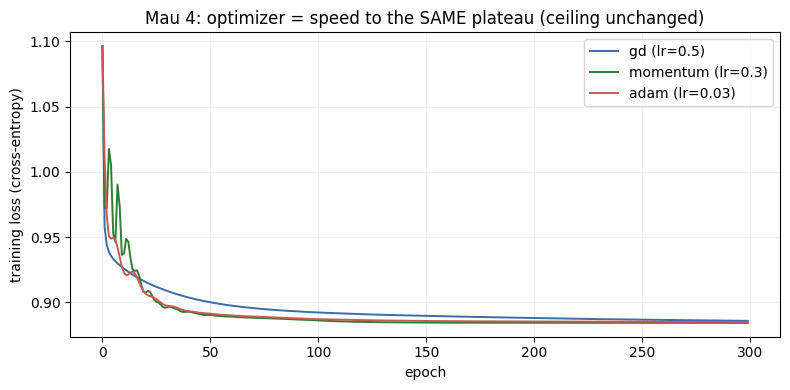

In [14]:
plt.figure(figsize=(8, 4)); cols = {"gd": "#3a6ea5", "momentum": "#2e7d32", "adam": "#c85a52"}
print(f"{'optimizer':12s}{'final loss':>11s}{'train':>7s}{'testT':>7s}{'testS':>7s}")
for opt, lr in [("gd", 0.5), ("momentum", 0.3), ("adam", 0.03)]:
    weights, biases, L = train_network([2, 8, 3], *data_lag["train"], opt=opt, epochs=300, lr=lr, l2=1e-3,
                                       act="relu", track=True, track_when="pre", adam_t="epoch")
    plt.plot(L, color=cols[opt], label=f"{opt} (lr={lr})", lw=1.4)
    print(f"{opt:12s}{L[-1]:11.4f}{100*accuracy(weights,biases,*data_lag['train']):6.1f}%"
          f"{100*accuracy(weights,biases,*data_lag['testT']):6.1f}%{100*accuracy(weights,biases,*data_lag['testS']):6.1f}%")
plt.xlabel("epoch"); plt.ylabel("training loss (cross-entropy)")
plt.title("Mau 4: optimizer = speed to the SAME plateau (ceiling unchanged)")
plt.legend(); plt.grid(True, color="#eef1f4"); plt.tight_layout(); plt.show()

Adam and momentum dive to the plateau in far fewer epochs, but the final loss and the test accuracy are the same across all three. The optimiser is a way to arrive faster, not a way to arrive somewhere better.

## Mau 5 - a disciplined hyperparameter search

Now we search - but with the rule that protects us: declare the budget up front, **select the winner on validation only**, and open the sealed test once for that winner alone. Judging the winner by its search rank is exactly how people fool themselves.

In [15]:
grid = [(arch, lr, l2)
        for arch in ([2,8,3], [2,16,3], [2,32,16,3], [2,64,32,3])
        for lr in (0.03, 0.05, 0.1)
        for l2 in (1e-4, 1e-3, 1e-2)]
print(f"SEARCH BUDGET = {len(grid)} configs (4 arch x 3 lr x 3 l2), optimizer=adam, epochs=300. Select on VALIDATION.")
res = []
for arch, lr, l2 in grid:
    weights, biases, _ = train_network(arch, *data_lag["train"], opt="adam", epochs=300, lr=lr, l2=l2,
                                       seed=0, act="relu", adam_t="epoch")
    res.append((accuracy(weights, biases, *data_lag["val"]), arch, lr, l2, weights, biases))
vals = np.array([r[0] for r in res]); res.sort(key=lambda r: -r[0]); best = res[0]
print(f"VAL accuracy over {len(grid)} configs: best={100*vals.max():.1f}%  mean={100*vals.mean():.1f}%  worst={100*vals.min():.1f}%")
print(f"  selection inflation (best-mean on val) = {100*(vals.max()-vals.mean()):.1f}%  (configs cluster => search buys little)")
weights, biases = best[4], best[5]
tT = accuracy(weights, biases, *data_lag["testT"]); tS = accuracy(weights, biases, *data_lag["testS"])
print(f"\nWINNER (best on VAL): arch={best[1]} lr={best[2]} l2={best[3]}")
print(f"  val = {100*best[0]:.1f}%   -->  SEALED TEST-time = {100*tT:.1f}%   TEST-symbol = {100*tS:.1f}%")
flag = " <-- ALARM" if max(tT, tS) > 60 else "  (no alarm)"
print(f"  ceiling check: test {100*max(tT,tS):.1f}% vs 60% threshold ->{flag}")

SEARCH BUDGET = 36 configs (4 arch x 3 lr x 3 l2), optimizer=adam, epochs=300. Select on VALIDATION.


VAL accuracy over 36 configs: best=53.7%  mean=51.5%  worst=49.8%
  selection inflation (best-mean on val) = 2.2%  (configs cluster => search buys little)

WINNER (best on VAL): arch=[2, 32, 16, 3] lr=0.03 l2=0.0001
  val = 53.7%   -->  SEALED TEST-time = 55.0%   TEST-symbol = 53.3%
  ceiling check: test 55.0% vs 60% threshold ->  (no alarm)


The 36 configs cluster tightly on validation, so the best is barely above the mean, and its sealed-test score lands right at persistence. The full search bought almost nothing over the naive rule - the honest reading is that there is little real edge to find here. The sharper winner's curse (a validation winner that is *worse* on the sealed test) shows up once we widen the search in Mau 8.

## Mau 6 - regularisation (L2 / dropout / early stopping)

We test regularisation on the model that overfit most - the richer 12-month input, which trained well above its test score. L2 shrinks weights, dropout randomly zeros hidden units during training (rescaled to keep the mean), and early stopping keeps the epoch with the best validation accuracy. The claim: regularisation shrinks the train-test *gap* but leaves the ceiling alone, because the overfit was noise, not skill.

In [16]:
print("Model C (richer input [12,32,3]) - regularization effect (train / testT / testS / gap=train-testT):")
def show(name, **kw):
    weights, biases, _ = train_network([K, 32, 3], *data_rich["train"], *data_rich["val"],
                                       opt="adam", epochs=300, lr=0.03, act="relu", adam_t="epoch", **kw)
    tr = 100*accuracy(weights, biases, *data_rich["train"])
    tt = 100*accuracy(weights, biases, *data_rich["testT"])
    ts = 100*accuracy(weights, biases, *data_rich["testS"])
    print(f"  {name:22s} train={tr:5.1f}%  testT={tt:5.1f}%  testS={ts:5.1f}%  gap={tr-tt:+5.1f}")
show("none (l2=1e-4)", l2=1e-4)
show("strong L2 (1e-1)", l2=1e-1)
show("dropout 0.3", l2=1e-4, drop=0.3)
show("early-stopping", l2=1e-4, early=True)

Model C (richer input [12,32,3]) - regularization effect (train / testT / testS / gap=train-testT):


  none (l2=1e-4)         train= 66.8%  testT= 52.4%  testS= 54.9%  gap=+14.4


  strong L2 (1e-1)       train= 57.8%  testT= 55.8%  testS= 54.2%  gap= +1.9


  dropout 0.3            train= 63.4%  testT= 54.5%  testS= 55.5%  gap= +8.9


  early-stopping         train= 66.6%  testT= 52.4%  testS= 54.3%  gap=+14.1


Strong L2 and dropout both close most of the train-test gap, and every variant still tests near 54%. Regularisation removed the fitted noise and left the (small) real skill untouched - exactly what it should do when the overfit was noise all along.

## Mau 7 - gradient-descent variants and activation functions

Two more toolbox items, each done carefully - every activation uses its own exact derivative in the backward pass. Part A varies the batch size (full / mini-256 / mini-32 / SGD-1); Part B swaps the activation (ReLU / leaky / tanh / sigmoid). Neither should move the ceiling; batch size changes convergence noise, activation changes dynamics.

(A) GD variants [2,8,3], SGD lr=0.1 (persistence testT 53.9%):
  batch      final loss  train  testT  testS


  full           0.8941  58.0%  55.4%  53.4%
  mini-256       0.8899  58.0%  56.4%  53.8%


  mini-32        0.8845  58.6%  56.1%  53.8%


  SGD-1          0.9304  57.1%  55.4%  54.1%


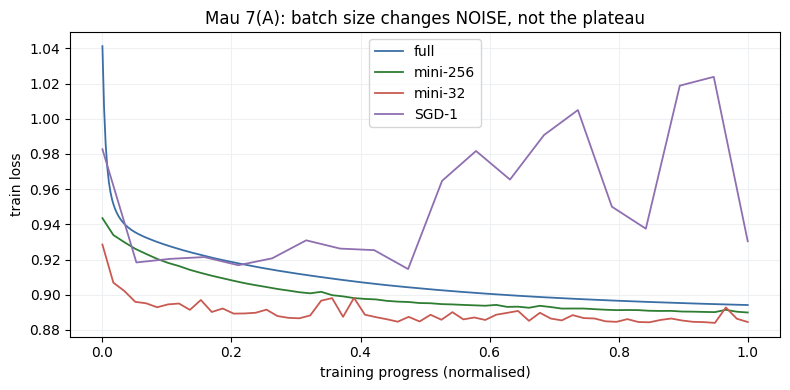


(B) Activations [2,8,3], Adam lr=0.03 (persistence testT 53.9%):
  activation final loss  train  testT  testS


  relu           0.8844  58.4%  56.1%  53.7%


  leaky          0.8845  58.4%  56.0%  53.7%


  tanh           0.8846  58.3%  55.9%  54.0%


  sigmoid        0.8879  58.2%  56.0%  53.7%


In [17]:
# (A) batch size, plain SGD lr=0.1
plt.figure(figsize=(8, 4)); cc = {"full": "#3a6ea5", "mini-256": "#2e7d32", "mini-32": "#c85a52", "SGD-1": "#8e6fb0"}
print("(A) GD variants [2,8,3], SGD lr=0.1 (persistence testT 53.9%):")
print(f"  {'batch':10s}{'final loss':>11s}{'train':>7s}{'testT':>7s}{'testS':>7s}")
for name, bz in [("full", None), ("mini-256", 256), ("mini-32", 32), ("SGD-1", 1)]:
    ep = 400 if bz is None else (60 if bz >= 32 else 20)
    weights, biases, L = train_network([2, 8, 3], *data_lag["train"], act="relu", opt="gd", batch=bz,
                                       epochs=ep, lr=0.1, track=True, track_when="post", adam_t="step")
    plt.plot(np.linspace(0, 1, len(L)), L, color=cc[name], label=f"{name}", lw=1.3)
    print(f"  {name:10s}{L[-1]:11.4f}{100*accuracy(weights,biases,*data_lag['train']):6.1f}%"
          f"{100*accuracy(weights,biases,*data_lag['testT']):6.1f}%{100*accuracy(weights,biases,*data_lag['testS']):6.1f}%")
plt.xlabel("training progress (normalised)"); plt.ylabel("train loss")
plt.title("Mau 7(A): batch size changes NOISE, not the plateau")
plt.legend(); plt.grid(True, color="#eef1f4"); plt.tight_layout(); plt.show()
# (B) activation, Adam lr=0.03
print("\n(B) Activations [2,8,3], Adam lr=0.03 (persistence testT 53.9%):")
print(f"  {'activation':10s}{'final loss':>11s}{'train':>7s}{'testT':>7s}{'testS':>7s}")
for a in ["relu", "leaky", "tanh", "sigmoid"]:
    accs = {k: [] for k in ("tr", "tt", "ts")}; ll = []
    for sd in (0, 1, 2):
        weights, biases, L = train_network([2, 8, 3], *data_lag["train"], act=a, opt="adam",
                                           epochs=300, lr=0.03, seed=sd, track=True, track_when="post", adam_t="step")
        accs["tr"].append(accuracy(weights, biases, *data_lag["train"], a))
        accs["tt"].append(accuracy(weights, biases, *data_lag["testT"], a))
        accs["ts"].append(accuracy(weights, biases, *data_lag["testS"], a)); ll.append(L[-1])
    print(f"  {a:10s}{np.mean(ll):11.4f}{100*np.mean(accs['tr']):6.1f}%{100*np.mean(accs['tt']):6.1f}%{100*np.mean(accs['ts']):6.1f}%")

Batch size only reshapes the noise on the loss curve, and the activations all land in the same 53-56% band; sigmoid is a touch slower to fall, the visible fingerprint of its vanishing gradient. Different dynamics, same ceiling.

## Mau 8 - the big combined search (the whole board of knobs at once)

A random search over architecture x optimiser x activation x input x learning rate x L2 x dropout. Same discipline: declare the budget, select on validation, and do **not** open the sealed test here - that is deferred to the Mau 9 reality check for all candidates together. Watch the best-validation score climb as the search widens: that climb is the winner's curse, and only the sealed test will tell us whether it is real.

In [18]:
rng = np.random.default_rng(0); N = 120
archs = [[8], [16], [32], [32, 16], [64, 32], [64, 32, 16]]; opts = ["gd", "momentum", "adam"]; acts = ["relu", "leaky", "tanh"]
val_hist = []; BIG = None
for c in range(N):
    hid = archs[rng.integers(len(archs))]; opt = opts[rng.integers(len(opts))]; act = acts[rng.integers(len(acts))]
    inp = "rich" if rng.random() < 0.5 else "small"; dataset = data_rich if inp == "rich" else data_lag
    lr = 10 ** rng.uniform(-2.5, -1) if opt == "adam" else 10 ** rng.uniform(-2, -0.4)
    l2 = 10 ** rng.uniform(-5, -1); drop = float(rng.choice([0, 0.1, 0.3, 0.5]))
    sizes = [dataset["train"][0].shape[1]] + hid + [3]
    weights, biases, _ = train_network(sizes, *dataset["train"], act=act, opt=opt, epochs=150,
                                       lr=lr, l2=l2, drop=drop, seed=0, adam_t="epoch")
    va = accuracy(weights, biases, *dataset["val"], act); val_hist.append(va)
    cfg = dict(hid=hid, opt=opt, act=act, inp=inp, lr=round(lr, 4), l2=round(l2, 6), drop=drop)
    if BIG is None or va > BIG[0]: BIG = (va, cfg)
vh = np.array(val_hist)
print(f"BIG SEARCH budget = {N} random combos over arch x opt x act x input x lr x l2 x dropout")
print(f"VAL: best={100*vh.max():.1f}%  mean={100*vh.mean():.1f}%  (mau-5 small-search best-val was 53.7%)")
for ck in (10, 40, 80, 120):
    print(f"  best-VAL after {ck:3d} combos = {100*max(val_hist[:ck]):.1f}%   <- climbs with search (winner's curse)")
print(f"WINNER (best on VAL): {BIG[1]}  val={100*BIG[0]:.1f}%")
BIG_CFG = BIG[1]
print("*** sealed TEST NOT opened here - deferred to mau 9 reality-check for ALL candidates. ***")

BIG SEARCH budget = 120 random combos over arch x opt x act x input x lr x l2 x dropout
VAL: best=54.8%  mean=50.9%  (mau-5 small-search best-val was 53.7%)
  best-VAL after  10 combos = 54.4%   <- climbs with search (winner's curse)
  best-VAL after  40 combos = 54.4%   <- climbs with search (winner's curse)
  best-VAL after  80 combos = 54.8%   <- climbs with search (winner's curse)
  best-VAL after 120 combos = 54.8%   <- climbs with search (winner's curse)
WINNER (best on VAL): {'hid': [64, 32], 'opt': 'momentum', 'act': 'tanh', 'inp': 'rich', 'lr': 0.1197, 'l2': 0.000187, 'drop': 0.1}  val=54.8%
*** sealed TEST NOT opened here - deferred to mau 9 reality-check for ALL candidates. ***


The best-validation score ratchets upward the longer we search, even though nothing about the problem changed - that is selection inflation in the act. The winner looks the best it has, on validation. Whether that survives contact with the sealed test is the next, and final, question.

## Mau 9 - the reality check: open the sealed test once, for everyone

"Useful in reality" is more than accuracy. We demand three things at once: beat the base rate, carry **trustworthy probabilities** (calibration, measured by expected calibration error - lower is better), and **generalise to unseen markets** (the test-symbol split). We retrain the shortlist on train, open the sealed test a single time, and let the numbers speak.

In [19]:
def ece(probs, y, bins=10):
    conf = probs.max(1); pred = probs.argmax(1); cor = (pred == y).astype(float); e = 0.0
    for b in range(bins):
        m = (conf > b/bins) & (conf <= (b+1)/bins)
        if m.sum() > 0: e += (m.mean()) * abs(cor[m].mean() - conf[m].mean())
    return e
def nparams(sizes): return sum(sizes[i]*sizes[i+1] + sizes[i+1] for i in range(len(sizes)-1))
# retrain the shortlist on TRAIN
W_log = fit_log(*data_lag["train"])
weights_simple, biases_simple, _ = train_network([2, 8, 3], *data_lag["train"], act="relu", opt="adam",
                                                 epochs=150, lr=0.03, l2=1e-3, drop=0.0, seed=0, adam_t="epoch")
weights_mau4, biases_mau4, _ = train_network([2, 32, 16, 3], *data_lag["train"], act="relu", opt="adam",
                                             epochs=150, lr=0.03, l2=1e-4, drop=0.0, seed=0, adam_t="epoch")
c = BIG_CFG; bigsizes = [12] + c["hid"] + [3]
weights_big, biases_big, _ = train_network(bigsizes, *data_rich["train"], act=c["act"], opt=c["opt"],
                                           epochs=150, lr=c["lr"], l2=c["l2"], drop=c["drop"], seed=0, adam_t="epoch")
def Plog(X): return softmax(np.column_stack([X, np.ones(len(X))]) @ W_log)
def perhot(X):
    p = np.where(X[:, 0] > 0.5, 2, np.where(X[:, 0] < -0.5, 0, 1)); probs = np.zeros((len(X), 3)); probs[np.arange(len(X)), p] = 1.0; return probs
CAND = [
    ("persistence (rule)",    lambda k: perhot(data_lag[k][0]),                          lambda k: data_lag[k][1], 0),
    ("logistic",              lambda k: Plog(data_lag[k][0]),                            lambda k: data_lag[k][1], 9),
    ("MLP simple [2,8,3]",    lambda k: probs_mlp(weights_simple, biases_simple, data_lag[k][0], "relu"), lambda k: data_lag[k][1], nparams([2,8,3])),
    ("MLP mau4 [2,32,16,3]",  lambda k: probs_mlp(weights_mau4, biases_mau4, data_lag[k][0], "relu"),     lambda k: data_lag[k][1], nparams([2,32,16,3])),
    ("BIG-search winner",     lambda k: probs_mlp(weights_big, biases_big, data_rich[k][0], c["act"]),    lambda k: data_rich[k][1], nparams(bigsizes)),
]
print("SEALED TEST opened once. base-rate testT~42% testS~41%. Persistence testT 53.9%.")
print(f"{'candidate':22s}{'params':>7s}{'testT':>7s}{'testS':>7s}{'ECE(testT)':>11s}")
for name, Pf, yf, pr in CAND:
    PT = Pf("testT"); yT = yf("testT"); PS = Pf("testS"); yS = yf("testS")
    aT = 100*np.mean(PT.argmax(1) == yT); aS = 100*np.mean(PS.argmax(1) == yS)
    flag = " <--ALARM" if max(aT, aS) > 60 else ""
    print(f"{name:22s}{pr:7d}{aT:6.1f}%{aS:6.1f}%{ece(PT, yT):11.3f}{flag}")

SEALED TEST opened once. base-rate testT~42% testS~41%. Persistence testT 53.9%.
candidate              params  testT  testS ECE(testT)
persistence (rule)          0  53.9%  54.7%      0.461
logistic                    9  56.4%  53.8%      0.028
MLP simple [2,8,3]         51  56.4%  53.7%      0.012
MLP mau4 [2,32,16,3]      675  56.4%  53.9%      0.026
BIG-search winner        3011  54.2%  52.8%      0.069


The verdict is quiet and clear. Every candidate sits near persistence on accuracy, no alarm fires, and the separation is in **calibration**: the small simple MLP carries by far the most trustworthy probabilities (lowest ECE), while the 3000-parameter big-search winner is both slightly less accurate and noticeably worse calibrated. Lower ECE means you can act on the percentage; the test-symbol column confirms it holds up on markets it never saw. The disciplined small model wins - not by scoring higher, but by being honest.

### DL method families (survey) - and why an MLP fits this problem
- **MLP / feed-forward** - universal approximator on a fixed feature vector. *(what we use)*
- **CNN** - exploits local / translation structure (images, 1-D signals). No such structure in `[current z, lag1]`.
- **RNN / LSTM / GRU** - model sequential dependence; our 'richer' input is a short vol-z sequence, but the feature lab showed extra lags add ~0, so a recurrent net is overkill.
- **Transformers / attention** - long-range dependence, large data; vastly over-parameterised for ~5000 samples and ~2 informative features.

**Why MLP here:** the real signal is a simple low-dimensional map (recent volatility -> next band). A tiny MLP - or even logistic regression - captures it, and Mau 7 showed fancier models add only overfit, not skill (and worse calibration). Refs: Rumelhart-Hinton-Williams 1986 (backprop); Kingma & Ba 2015 (Adam); Guo et al. 2017 (calibration of neural nets).

## The forecast in action - using it like a weather app (the point of the whole thing)

The winning model reads each market's recent volatility and issues a next-month **weather forecast: % calm / normal / stormy**. Two honesty notes on what follows. The top panel is **US500 on a sealed test-time window** - a market the model *did* train on, but only on earlier months; these forecasts are for a time slice it never saw. The bottom two panels and the diary use the **genuinely unseen held-out markets** (US2000, NZDUSD, ETHUSD, UKOIL) - symbols the model never trained on at all. Together: (top) forecast vs what actually happened on a seen market's sealed window; (bottom-left) can you trust the % on unseen markets - when it says X% stormy, does it storm X%; (bottom-right) does acting on the warning pay off. Then a month-by-month usage diary and live forecasts.

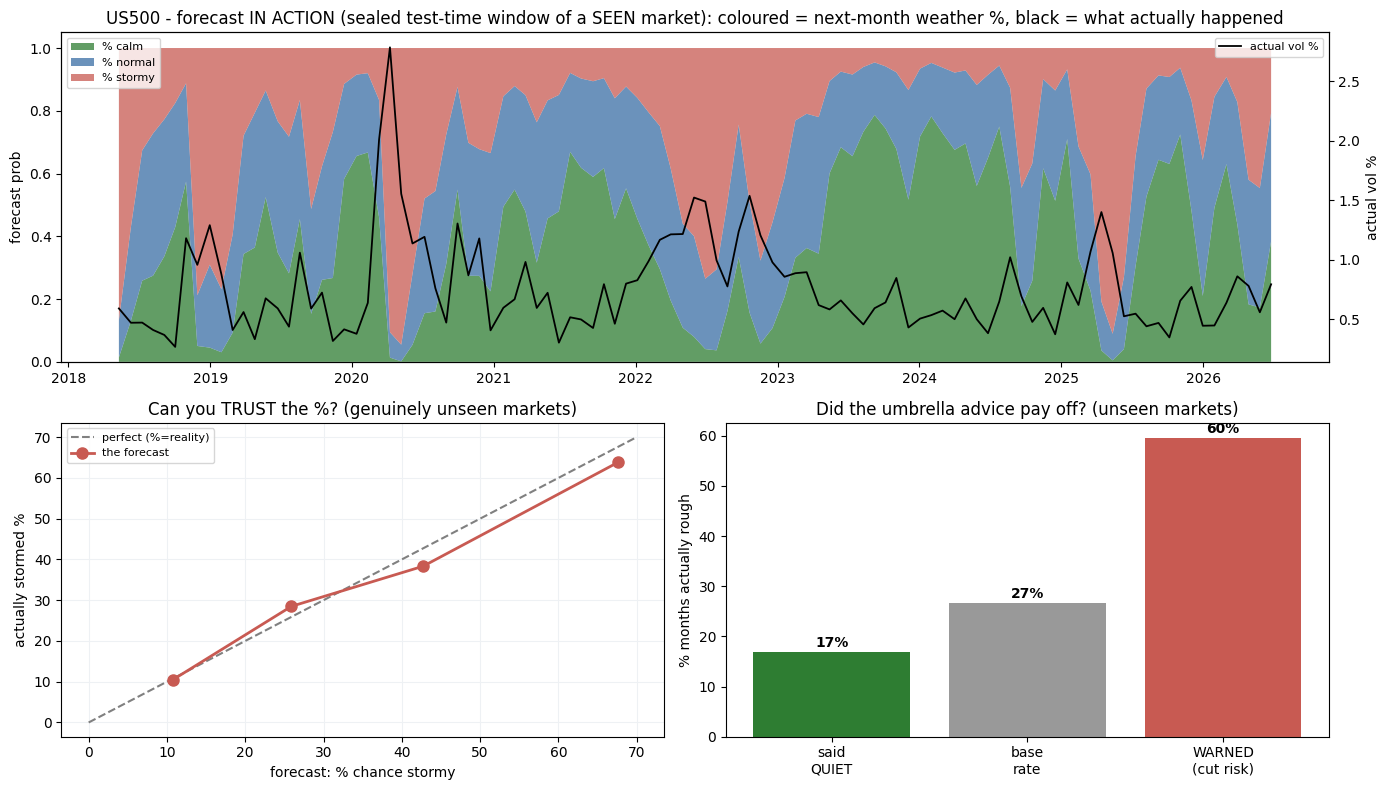

USAGE DIARY - ETHUSD (NEVER trained on), recent months (honest: hits, misses AND false alarms):
  2025-11-27: forecast STORMY (50% storm) | next month NORMAL vol 3.1%  false alarm
  2025-12-25: forecast NORMAL (35% storm) | next month CALM   vol 2.2%  ok/quiet
  2026-01-22: forecast CALM   ( 8% storm) | next month STORMY vol 4.4%  CAUGHT OUT
  2026-02-19: forecast STORMY (50% storm) | next month STORMY vol 3.6%  GOOD CALL
  2026-03-19: forecast STORMY (51% storm) | next month CALM   vol 2.2%  false alarm
  2026-04-16: forecast CALM   (13% storm) | next month CALM   vol 1.5%  ok/quiet
  2026-05-14: forecast CALM   ( 3% storm) | next month NORMAL vol 2.9%  ok/quiet
  2026-06-11: forecast CALM   ( 9% storm) | next month CALM   vol 2.3%  ok/quiet

LIVE next-month forecasts:
  US500   -> calm 28% | normal 44% | stormy 28%   (as of 2026-06-25)
  ETHUSD  -> calm 67% | normal 25% | stormy  8%   (as of 2026-07-09)
  XAUUSD  -> calm 12% | normal 31% | stormy 56%   (as of 2026-06-30)
  EURUSD  ->

In [20]:
def load_dated(name):
    D = []; C = []
    for r in csv.DictReader(open(f"{ROOT}/data/panel/{name}.csv")):
        try: c = float(r["Close"])
        except: continue
        if c <= 0: continue
        D.append(dt.date.fromisoformat(r["Date"])); C.append(c)
    if name in CRYPTO:
        k = [i for i, d in enumerate(D) if d.weekday() < 5]; D = [D[i] for i in k]; C = [C[i] for i in k]
    r = np.diff(np.log(np.array(C))); lo, hi = np.percentile(r, WINSOR); return D[1:], np.clip(r, lo, hi)
def build_sym(name, B=20):
    d, r = load_dated(name); nb = len(r) // B
    vol = np.array([np.mean(np.abs(r[i*B:(i+1)*B])) for i in range(nb)]); bd = [d[(i+1)*B-1] for i in range(nb)]
    return bd, vol, zser(vol)
BN = ["calm", "normal", "stormy"]; COL = ["#2e7d32", "#3a6ea5", "#c85a52"]
bd, vol, z = build_sym("US500"); idx = [t for t in range(25, len(z)-1) if not (np.isnan(z[t]) or np.isnan(z[t-1]))]
tix = idx[int(len(idx)*0.85):]
probs = probs_mlp(weights_simple, biases_simple, np.array([[z[t], z[t-1]] for t in tix]), "relu")
dts = [bd[t+1] for t in tix]; av = np.array([vol[t+1] for t in tix]) * 100
fig = plt.figure(figsize=(14, 8)); gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1])
axT = fig.add_subplot(gs[0, :]); axC = fig.add_subplot(gs[1, 0]); axU = fig.add_subplot(gs[1, 1])
axT.stackplot(dts, probs[:, 0], probs[:, 1], probs[:, 2], colors=COL, alpha=.75, labels=["% calm", "% normal", "% stormy"])
ax2 = axT.twinx(); ax2.plot(dts, av, color="black", lw=1.3, label="actual vol %")
axT.set_title("US500 - forecast IN ACTION (sealed test-time window of a SEEN market): coloured = next-month weather %, black = what actually happened")
axT.set_ylabel("forecast prob"); ax2.set_ylabel("actual vol %"); axT.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); axT.margins(x=0)
ps = []; ac = []
for s in ["US2000", "NZDUSD", "ETHUSD", "UKOIL"]:
    b2, v2, z2 = build_sym(s); ix = [t for t in range(25, len(z2)-1) if not (np.isnan(z2[t]) or np.isnan(z2[t-1]))]
    Ps = probs_mlp(weights_simple, biases_simple, np.array([[z2[t], z2[t-1]] for t in ix]), "relu")
    ps += list(Ps[:, 2]); ac += [1 if (2 if z2[t+1] > 0.5 else (0 if z2[t+1] < -0.5 else 1)) == 2 else 0 for t in ix]
ps = np.array(ps); ac = np.array(ac); xc = []; yc = []
for lo, hi in [(0, 0.2), (0.2, 0.35), (0.35, 0.5), (0.5, 1.01)]:
    m = (ps >= lo) & (ps < hi)
    if m.sum() > 5: xc.append(100*ps[m].mean()); yc.append(100*ac[m].mean())
axC.plot([0, 70], [0, 70], "--", color="gray", label="perfect (%=reality)"); axC.plot(xc, yc, "o-", color=COL[2], lw=2, ms=8, label="the forecast")
axC.set_title("Can you TRUST the %? (genuinely unseen markets)"); axC.set_xlabel("forecast: % chance stormy"); axC.set_ylabel("actually stormed %"); axC.legend(fontsize=8); axC.grid(True, color="#eef1f4")
warn = ps >= 0.45; bars = [100*ac[~warn].mean(), 100*ac.mean(), 100*ac[warn].mean()]
axU.bar([0, 1, 2], bars, color=[COL[0], "#999", COL[2]]); axU.set_xticks([0, 1, 2]); axU.set_xticklabels(["said\nQUIET", "base\nrate", "WARNED\n(cut risk)"])
axU.set_title("Did the umbrella advice pay off? (unseen markets)"); axU.set_ylabel("% months actually rough")
for i, bb in enumerate(bars): axU.text(i, bb+1, f"{bb:.0f}%", ha="center", weight="bold")
plt.tight_layout(); plt.show()
print("USAGE DIARY - ETHUSD (NEVER trained on), recent months (honest: hits, misses AND false alarms):")
bd, vol, z = build_sym("ETHUSD"); ix = [t for t in range(25, len(z)-1) if not (np.isnan(z[t]) or np.isnan(z[t-1]))]; BNS = ["CALM", "NORMAL", "STORMY"]
for t in ix[-8:]:
    p = probs_mlp(weights_simple, biases_simple, np.array([[z[t], z[t-1]]]), "relu")[0]; fb = int(p.argmax()); ab = 2 if z[t+1] > 0.5 else (0 if z[t+1] < -0.5 else 1)
    v = "GOOD CALL" if (fb == 2 and ab == 2) else ("false alarm" if (fb == 2 and ab < 2) else ("CAUGHT OUT" if (fb < 2 and ab == 2) else "ok/quiet"))
    print(f"  {bd[t]}: forecast {BNS[fb]:6s} ({100*p[2]:2.0f}% storm) | next month {BNS[ab]:6s} vol {vol[t+1]*100:.1f}%  {v}")
print("\nLIVE next-month forecasts:")
for s in ["US500", "ETHUSD", "XAUUSD", "EURUSD"]:
    b3, v3, z3 = build_sym(s); t = len(z3) - 1
    while t > 25 and (np.isnan(z3[t]) or np.isnan(z3[t-1])): t -= 1
    p = probs_mlp(weights_simple, biases_simple, np.array([[z3[t], z3[t-1]]]), "relu")[0]
    print(f"  {s:7s} -> calm {100*p[0]:2.0f}% | normal {100*p[1]:2.0f}% | stormy {100*p[2]:2.0f}%   (as of {b3[t]})")

Read as a habit rather than a crystal ball, the forecast earns its place: on unseen markets its stated storm-probabilities track how often it actually stormed (the calibration line hugs the diagonal), and months it warned about were rougher than average. The diary keeps it honest - there are false alarms and one caught-out month in any eight. The bottom line is a trustworthy, humble tilt: trust the %, and over many months it tips the odds your way. That modesty is the point.

### The three usage claims, printed exactly

The panels above are drawn, but their headline numbers live only inside the plot. Here we print them so the prose can quote them directly. Everything is pooled across the four genuinely held-out markets (US2000, NZDUSD, ETHUSD, UKOIL) and recomputed from `weights_simple`, so this block stands on its own.

In [21]:
# recompute the pooled held-out forecasts, standing on its own (weights_simple, seed 0)
held_fb = []       # forecast band: 0 calm / 1 normal / 2 stormy
held_storm_p = []  # forecast storm probability
held_rough = []    # next-month realized roughness = mean|ret| of the NEXT block
held_actual = []   # 1 if next month was actually stormy
for s in ["US2000", "NZDUSD", "ETHUSD", "UKOIL"]:
    b2, v2, z2 = build_sym(s)
    ix = [t for t in range(25, len(z2) - 1) if not (np.isnan(z2[t]) or np.isnan(z2[t-1]))]
    P = probs_mlp(weights_simple, biases_simple, np.array([[z2[t], z2[t-1]] for t in ix]), "relu")
    held_fb += list(P.argmax(1))
    held_storm_p += list(P[:, 2])
    held_rough += [v2[t+1] for t in ix]
    held_actual += [1 if (2 if z2[t+1] > 0.5 else (0 if z2[t+1] < -0.5 else 1)) == 2 else 0 for t in ix]
held_fb = np.array(held_fb); held_storm_p = np.array(held_storm_p)
held_rough = np.array(held_rough); held_actual = np.array(held_actual)
print(f"pooled held-out months: n = {len(held_fb)}")

pooled held-out months: n = 1027


**Claim 1 - the labels line up with reality.** Group next-month realized roughness (mean $|r|$ per day) by the band the forecast called, then compare the stormy-label months against the calm-label months.

In [22]:
rough_calm = held_rough[held_fb == 0].mean()
rough_stormy = held_rough[held_fb == 2].mean()
print(f"mean next-month roughness | called CALM   = {100*rough_calm:.3f}% per day  (n={int((held_fb==0).sum())})")
print(f"mean next-month roughness | called STORMY = {100*rough_stormy:.3f}% per day  (n={int((held_fb==2).sum())})")
print(f"stormy / calm roughness ratio = {rough_stormy / rough_calm:.2f}x")

mean next-month roughness | called CALM   = 0.992% per day  (n=540)
mean next-month roughness | called STORMY = 1.438% per day  (n=283)
stormy / calm roughness ratio = 1.45x


**Claim 2 - the calibration curve, as numbers.** Bin the forecast storm-probability, and in each bin compare the average promised chance (forecast %) against how often it actually stormed (actual %) - the two coordinates of every point on the calibration line.

In [23]:
print(f"{'forecast storm %':>18s}{'actual storm %':>16s}{'n':>6s}")
for lo, hi in [(0, 0.2), (0.2, 0.35), (0.35, 0.5), (0.5, 1.01)]:
    m = (held_storm_p >= lo) & (held_storm_p < hi)
    if m.sum() > 5:
        print(f"{100*held_storm_p[m].mean():17.0f}%{100*held_actual[m].mean():15.0f}%{int(m.sum()):6d}")

  forecast storm %  actual storm %     n
               11%             10%   544
               26%             28%   172
               43%             38%   120
               68%             64%   191


**Claim 3 - does the umbrella advice pay off?** The base rate of stormy months across the held-out markets, versus the months the model warned about (storm probability at least 45%) and the months it called quiet.

In [24]:
warn = held_storm_p >= 0.45
print(f"base rate (all held-out months) = {100*held_actual.mean():.0f}% stormy")
print(f"months it WARNED (storm >= 45%)  = {100*held_actual[warn].mean():.0f}% stormy")
print(f"months it called QUIET          = {100*held_actual[~warn].mean():.0f}% stormy")

base rate (all held-out months) = 27% stormy
months it WARNED (storm >= 45%)  = 60% stormy
months it called QUIET          = 17% stormy
